# Mini Project 1: Open-Meteo Winter Weather Analysis

## 1. Overview

This notebook compares daily winter weather across eight U.S. cities using historical data from the **Open-Meteo Historical Weather API**.

### What is this dataset?

Each row is **one city on one day** from **December 1, 2025 through February 28, 2026**. The columns include date, city, region, temperature, apparent (“feels like”) temperature, humidity, cloud cover, precipitation, wind, and location metadata.

### Where did it come from?

The data was downloaded from the Open-Meteo archive endpoint (`https://archive-api.open-meteo.com/v1/archive`) using fixed latitude/longitude coordinates for:

Seattle, Phoenix, Miami, Chicago, New York City, Los Angeles, Denver, and New Orleans.

A local copy is saved at `data/open_meteo_historical_weather_daily.csv`.

### What questions am I trying to answer?

1. Which city had the biggest average difference between actual temperature and “feels like” temperature?
2. Which city had the highest average humidity, and how does Seattle compare to the others?
3. Which cities had the most cloudy, rainy, or clear days, and are there any rough patterns by region?

### Why do these questions matter?

I was curious about how winter weather *feels* different across cities — not just the number on a thermometer. Humidity, wind, and cloud cover can change how cold or damp a day feels. Comparing many daily rows across a full winter season makes those patterns easier to see than a single “current weather” snapshot would.

I originally thought about comparing **current** weather, but that would only give **one row per city**. I pivoted to **historical daily weather** so pandas could group, filter, and summarize meaningful patterns over time.

Because each region label in this project represents **only one city**, any regional comparison should be treated as a rough snapshot, not a claim about an entire region.

In [1]:
!pip install jupyter plotly kaleido pandas


zsh:1: command not found: pip


### Setup: import libraries

This notebook uses Python’s standard library for API requests, `pandas` for analysis, and `matplotlib` for charts.

In [2]:
import json
import time
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

import matplotlib.pyplot as plt
import pandas as pd

### Data collection: cities and API settings

The next cells request historical daily weather from Open-Meteo for each city, save a CSV copy, and reload it with pandas.

In [3]:
# Each dictionary stores the city name, a broad region label, and coordinates.
# The region label lets us do a basic regional comparison later, while the coordinates tell the API where to get weather data.
cities = [
    {"city": "Seattle", "state": "WA", "region": "Pacific Northwest", "latitude": 47.6062, "longitude": -122.3321},
    {"city": "Phoenix", "state": "AZ", "region": "Southwest", "latitude": 33.4484, "longitude": -112.0740},
    {"city": "Miami", "state": "FL", "region": "Southeast", "latitude": 25.7617, "longitude": -80.1918},
    {"city": "Chicago", "state": "IL", "region": "Midwest", "latitude": 41.8781, "longitude": -87.6298},
    {"city": "New York City", "state": "NY", "region": "Northeast", "latitude": 40.7128, "longitude": -74.0060},
    {"city": "Los Angeles", "state": "CA", "region": "West Coast", "latitude": 34.0522, "longitude": -118.2437},
    {"city": "Denver", "state": "CO", "region": "Mountain West", "latitude": 39.7392, "longitude": -104.9903},
    {"city": "New Orleans", "state": "LA", "region": "Gulf South", "latitude": 29.9511, "longitude": -90.0715},
]

# I chose a full winter season so the dataset is large enough for meaningful pandas analysis.
# This gives about 90 daily rows per city instead of only one current-weather row per city.
START_DATE = "2025-12-01"
END_DATE = "2026-02-28"

# These daily variables match the questions: temperature, feels-like temperature, humidity, clouds, rain, snow, and wind.
# The API will return one value per day for each selected variable.
daily_variables = [
    "weather_code",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_mean",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "wind_speed_10m_mean",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
]

BASE_URL = "https://archive-api.open-meteo.com/v1/archive"

### Data collection: download from Open-Meteo

This loop requests one winter season of daily records per city and combines them into one DataFrame.

In [4]:
def fetch_city_weather(city_info):
    """Fetch daily historical weather data for one city and return it as a DataFrame."""

    params = {
        "latitude": city_info["latitude"],
        "longitude": city_info["longitude"],
        "start_date": START_DATE,
        "end_date": END_DATE,
        "daily": ",".join(daily_variables),
        "temperature_unit": "fahrenheit",
        "wind_speed_unit": "mph",
        "precipitation_unit": "inch",
        "timezone": "auto",
    }

    url = f"{BASE_URL}?{urlencode(params)}"

    with urlopen(url) as response:
        data = json.loads(response.read().decode("utf-8"))

    # The API stores the daily values in a nested "daily" dictionary.
    # Turning that dictionary into a DataFrame creates one row per day for this city.
    city_df = pd.DataFrame(data["daily"])

    # Add city details to every row so the combined dataset still knows which city each day belongs to.
    city_df["city"] = city_info["city"]
    city_df["state"] = city_info["state"]
    city_df["region"] = city_info["region"]
    city_df["latitude"] = city_info["latitude"]
    city_df["longitude"] = city_info["longitude"]

    return city_df


all_city_dfs = []

for city in cities:
    print(f"Fetching weather data for {city['city']}...")
    city_weather = fetch_city_weather(city)
    all_city_dfs.append(city_weather)

    # A tiny pause is polite to the API and makes it less likely that repeated runs will hit request limits.
    time.sleep(0.2)

weather_df = pd.concat(all_city_dfs, ignore_index=True)

print(f"Collected {len(weather_df)} rows and {len(weather_df.columns)} columns.")
weather_df.head()

Fetching weather data for Seattle...


Fetching weather data for Phoenix...


Fetching weather data for Miami...


Fetching weather data for Chicago...


Fetching weather data for New York City...


Fetching weather data for Los Angeles...


Fetching weather data for Denver...


Fetching weather data for New Orleans...


Collected 720 rows and 21 columns.


,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_mean,cloud_cover_mean,...,rain_sum,snowfall_sum,wind_speed_10m_mean,wind_speed_10m_max,wind_gusts_10m_max,city,state,region,latitude,longitude
0,2025-12-01,51,41.3,45.3,37.1,37.4,41.4,33.0,86,85,...,0.008,0.0,2.2,5.0,10.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
1,2025-12-02,61,44.3,48.0,40.9,40.4,43.3,37.7,88,65,...,0.157,0.0,4.0,7.3,16.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
2,2025-12-03,51,43.1,45.5,40.5,40.0,42.9,36.9,92,100,...,0.016,0.0,2.0,4.3,7.6,Seattle,WA,Pacific Northwest,47.6062,-122.3321
3,2025-12-04,55,44.4,46.3,42.6,40.2,43.6,37.8,93,100,...,0.508,0.0,5.6,9.1,16.3,Seattle,WA,Pacific Northwest,47.6062,-122.3321
4,2025-12-05,63,49.8,55.2,45.8,43.6,48.1,41.2,90,96,...,0.579,0.0,12.9,22.5,43.4,Seattle,WA,Pacific Northwest,47.6062,-122.3321


### Data collection: save local CSV

Saving the dataset makes the project easier to rerun without repeating every API call.

In [5]:
data_folder = Path("data")
data_folder.mkdir(exist_ok=True)

csv_path = data_folder / "open_meteo_historical_weather_daily.csv"
weather_df.to_csv(csv_path, index=False)

print(f"Saved dataset to: {csv_path}")

Saved dataset to: data/open_meteo_historical_weather_daily.csv


### Data collection: load CSV with pandas

Reloading from the CSV keeps the analysis tied to a clear source file.

In [6]:
df = pd.read_csv(csv_path)

# Convert the time column into a true date type so pandas can sort, filter, and group it more reliably.
df["time"] = pd.to_datetime(df["time"])



## 2. Data Profile

These cells inspect the loaded dataset with `head()`, `info()`, `describe()`, and `isnull().sum()`.

In [7]:
df.head()


,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_mean,cloud_cover_mean,...,rain_sum,snowfall_sum,wind_speed_10m_mean,wind_speed_10m_max,wind_gusts_10m_max,city,state,region,latitude,longitude
0,2025-12-01,51,41.3,45.3,37.1,37.4,41.4,33.0,86,85,...,0.008,0.0,2.2,5.0,10.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
1,2025-12-02,61,44.3,48.0,40.9,40.4,43.3,37.7,88,65,...,0.157,0.0,4.0,7.3,16.1,Seattle,WA,Pacific Northwest,47.6062,-122.3321
2,2025-12-03,51,43.1,45.5,40.5,40.0,42.9,36.9,92,100,...,0.016,0.0,2.0,4.3,7.6,Seattle,WA,Pacific Northwest,47.6062,-122.3321
3,2025-12-04,55,44.4,46.3,42.6,40.2,43.6,37.8,93,100,...,0.508,0.0,5.6,9.1,16.3,Seattle,WA,Pacific Northwest,47.6062,-122.3321
4,2025-12-05,63,49.8,55.2,45.8,43.6,48.1,41.2,90,96,...,0.579,0.0,12.9,22.5,43.4,Seattle,WA,Pacific Northwest,47.6062,-122.3321


**`df.head()`:** Each row is one city-day. The columns include date, city, temperature, apparent temperature, humidity, cloud cover, precipitation, wind, and location fields.

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       720 non-null    datetime64[ns]
 1   weather_code               720 non-null    int64         
 2   temperature_2m_mean        720 non-null    float64       
 3   temperature_2m_max         720 non-null    float64       
 4   temperature_2m_min         720 non-null    float64       
 5   apparent_temperature_mean  720 non-null    float64       
 6   apparent_temperature_max   720 non-null    float64       
 7   apparent_temperature_min   720 non-null    float64       
 8   relative_humidity_2m_mean  720 non-null    int64         
 9   cloud_cover_mean           720 non-null    int64         
 10  precipitation_sum          720 non-null    float64       
 11  rain_sum                   720 non-null    float64       
 12  snowfall

**`df.info()`:** The dataset has 720 rows (90 days × 8 cities) and 21 columns. Most weather fields are numeric; `time`, `city`, `state`, and `region` are text or categorical. Converting `time` to datetime makes filtering and sorting safer.

In [9]:
df.describe()


,time,weather_code,temperature_2m_mean,temperature_2m_max,temperature_2m_min,apparent_temperature_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_mean,cloud_cover_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_10m_mean,wind_speed_10m_max,wind_gusts_10m_max,latitude,longitude
count,720,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2026-01-14 12:00:00,26.654167,47.734861,56.509028,40.094167,43.197778,52.449167,34.894722,67.275000,55.244444,0.086517,0.075289,0.078774,5.711944,9.370833,20.940139,36.643712,-98.692400
min,2025-12-01 00:00:00,0.000000,-4.100000,6.700000,-9.300000,-16.000000,-4.300000,-21.600000,16.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.300000,6.300000,25.761700,-122.332100
25%,2025-12-23 00:00:00,3.000000,36.250000,42.900000,29.000000,29.300000,37.500000,21.200000,55.000000,28.000000,0.000000,0.000000,0.000000,2.900000,5.800000,13.400000,32.574075,-113.616425
50%,2026-01-14 12:00:00,3.000000,48.950000,58.950000,42.300000,43.600000,54.150000,36.200000,71.000000,58.000000,0.000000,0.000000,0.000000,4.900000,8.850000,19.500000,36.895700,-97.530900
75%,2026-02-06 00:00:00,55.000000,60.025000,71.600000,51.300000,58.425000,69.625000,47.625000,83.000000,84.000000,0.043000,0.021000,0.000000,7.800000,12.000000,26.650000,41.004125,-85.770300
max,2026-02-28 00:00:00,75.000000,78.000000,91.200000,73.800000,83.800000,90.000000,79.200000,97.000000,100.000000,2.720000,2.720000,7.441000,18.700000,27.100000,55.500000,47.606200,-74.006000
std,NaN,29.220777,16.832495,17.944054,16.863229,20.162905,20.971708,20.087982,18.881504,32.206975,0.246606,0.238733,0.460462,3.395112,4.485974,9.414702,6.655278,16.997873


**`df.describe()`:** Daily mean temperatures range from about **-4°F to 78°F** (overall average near **48°F**). Average humidity is near **67%**, precipitation is usually small (mean **~0.09 in/day**), cloud cover averages **~55%**, and wind values vary enough to affect feels-like comparisons.

In [10]:
df.isnull().sum()


time                         0
weather_code                 0
temperature_2m_mean          0
temperature_2m_max           0
temperature_2m_min           0
apparent_temperature_mean    0
apparent_temperature_max     0
apparent_temperature_min     0
relative_humidity_2m_mean    0
cloud_cover_mean             0
precipitation_sum            0
rain_sum                     0
snowfall_sum                 0
wind_speed_10m_mean          0
wind_speed_10m_max           0
wind_gusts_10m_max           0
city                         0
state                        0
region                       0
latitude                     0
longitude                    0
dtype: int64

**`df.isnull().sum()` — missing values:**

1. **What does the data look like?** Long-format daily weather: one row per city per day.
2. **What types are the columns?** Dates, text categories (city/region), and numeric weather measurements.
3. **Are there missing values, and do they matter?** All columns show **0 missing values**, so the charts and groupby summaries are not affected by gaps in this dataset.

### Prepare analysis columns

Helper columns such as `feels_like_gap_f`, `absolute_feels_like_gap_f`, `weather_condition`, `is_rain_day`, `is_cloudy_day`, and `is_clear_day` make each research question easier to compute.

In [11]:
def classify_weather_code(code):
    """Turn Open-Meteo numeric weather codes into broader readable categories."""

    if pd.isna(code):
        return "Unknown"

    code = int(code)

    if code == 0:
        return "Clear"
    elif code in [1, 2, 3]:
        return "Partly cloudy/cloudy"
    elif code in [45, 48]:
        return "Fog"
    elif code in [51, 53, 55, 56, 57, 61, 63, 65, 66, 67, 80, 81, 82]:
        return "Rain/drizzle"
    elif code in [71, 73, 75, 77, 85, 86]:
        return "Snow"
    elif code in [95, 96, 99]:
        return "Thunderstorm"
    else:
        return "Other"


# This is the directional gap: negative means it felt colder than the actual temperature, positive means it felt warmer.
df["feels_like_gap_f"] = df["apparent_temperature_mean"] - df["temperature_2m_mean"]

# This is the size of the gap regardless of direction, which is useful for finding the biggest difference overall.
df["absolute_feels_like_gap_f"] = df["feels_like_gap_f"].abs()

# This turns the numeric weather code into a category that is easier to read and count.
df["weather_condition"] = df["weather_code"].apply(classify_weather_code)

# These true/false columns let us compare rainy, cloudy, and clear days across cities.
# A rainy day means the city had more than a tiny trace of precipitation.
df["is_rain_day"] = df["precipitation_sum"] > 0.01

# A cloudy day means the average cloud cover was at least 70%.
df["is_cloudy_day"] = df["cloud_cover_mean"] >= 70

# A clear day means the weather code was clear or the average cloud cover was very low.
df["is_clear_day"] = (df["weather_condition"] == "Clear") | (df["cloud_cover_mean"] <= 30)

# Show the new columns to check that the added variables make sense.
df[["time", "city", "temperature_2m_mean", "apparent_temperature_mean", "feels_like_gap_f", "weather_condition", "is_rain_day", "is_cloudy_day", "is_clear_day"]].head()

,time,city,temperature_2m_mean,apparent_temperature_mean,feels_like_gap_f,weather_condition,is_rain_day,is_cloudy_day,is_clear_day
0,2025-12-01,Seattle,41.3,37.4,-3.9,Rain/drizzle,False,True,False
1,2025-12-02,Seattle,44.3,40.4,-3.9,Rain/drizzle,True,False,False
2,2025-12-03,Seattle,43.1,40.0,-3.1,Rain/drizzle,True,True,False
3,2025-12-04,Seattle,44.4,40.2,-4.2,Rain/drizzle,True,True,False
4,2025-12-05,Seattle,49.8,43.6,-6.2,Rain/drizzle,True,True,False


In [12]:
# df['column'].value_counts() counts how often each weather condition appears in the full dataset.
# The answer tells me which broad weather categories were most common across all cities and all winter days.
df["weather_condition"].value_counts()

weather_condition
Partly cloudy/cloudy    376
Rain/drizzle            216
Snow                     83
Clear                    45
Name: count, dtype: int64

## 3. Analysis

### Question 1: Which city had the biggest average difference between actual temperature and “feels like” temperature?

In [13]:
# df.groupby('city')[...].mean() groups all daily rows by city and calculates each city's average values.
# The answer tells me which city had the biggest average gap between measured air temperature and experienced/feels-like temperature.
feels_like_by_city = (
    df.groupby("city")[["temperature_2m_mean", "apparent_temperature_mean", "feels_like_gap_f", "absolute_feels_like_gap_f"]]
    .mean()
    .sort_values("absolute_feels_like_gap_f", ascending=False)
)

feels_like_by_city.round(2)

,temperature_2m_mean,apparent_temperature_mean,feels_like_gap_f,absolute_feels_like_gap_f
city,,,,
Chicago,26.85,18.26,-8.60,8.60
New York City,28.40,20.56,-7.85,7.85
Denver,37.96,30.96,-7.01,7.01
Seattle,44.18,38.89,-5.29,5.29
Phoenix,60.89,56.55,-4.35,4.44
New Orleans,57.09,54.68,-2.41,3.90
Miami,68.77,69.47,0.70,3.39
Los Angeles,57.72,56.22,-1.50,1.77


In [14]:
# This pulls out the single city with the largest average absolute feels-like gap.
# The answer is the clearest direct response to Question 1.
biggest_gap_city = feels_like_by_city.index[0]
biggest_gap_value = feels_like_by_city.iloc[0]["absolute_feels_like_gap_f"]

print(f"The city with the biggest average feels-like gap was {biggest_gap_city}, with an average gap of {biggest_gap_value:.2f}°F.")

The city with the biggest average feels-like gap was Chicago, with an average gap of 8.60°F.


In [15]:
# This filter finds Seattle days where it felt at least 5°F colder than the actual mean temperature.
# The answer tells me whether Seattle had many days where wind/humidity/conditions made the weather feel noticeably colder.
seattle_cold_feel_days = df[(df["city"] == "Seattle") & (df["feels_like_gap_f"] <= -5)]

seattle_cold_feel_days[["time", "city", "temperature_2m_mean", "apparent_temperature_mean", "feels_like_gap_f", "wind_speed_10m_mean", "relative_humidity_2m_mean"]].head(10)

,time,city,temperature_2m_mean,apparent_temperature_mean,feels_like_gap_f,wind_speed_10m_mean,relative_humidity_2m_mean
4,2025-12-05,Seattle,49.8,43.6,-6.2,12.9,90
5,2025-12-06,Seattle,50.2,41.9,-8.3,16.4,81
6,2025-12-07,Seattle,50.3,44.7,-5.6,11.5,88
7,2025-12-08,Seattle,52.5,46.4,-6.1,14.6,91
9,2025-12-10,Seattle,55.7,49.0,-6.7,18.7,93
14,2025-12-15,Seattle,53.7,46.7,-7.0,16.5,86
15,2025-12-16,Seattle,51.0,44.4,-6.6,14.5,89
16,2025-12-17,Seattle,47.2,38.6,-8.6,15.2,78
17,2025-12-18,Seattle,47.2,39.7,-7.5,13.5,84
18,2025-12-19,Seattle,42.3,33.9,-8.4,12.9,81


In [16]:
charts_folder = Path("charts")
charts_folder.mkdir(exist_ok=True)

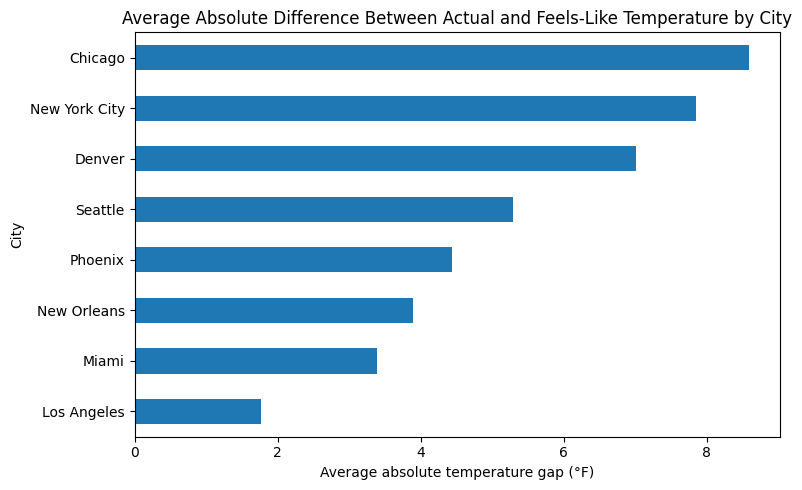

In [17]:
# Analytical question 1: Which city had the biggest average difference between actual temperature and "feels like" temperature?
# A horizontal bar chart fits because we compare one numeric value (average absolute gap in °F) across city categories, and long city names stay readable on the y-axis.
feels_like_by_city["absolute_feels_like_gap_f"].sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Average Absolute Difference Between Actual and Feels-Like Temperature by City")
plt.xlabel("Average absolute temperature gap (°F)")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(charts_folder / "feels_like_gap_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

**Chart 1 finding:** **Chicago** had the largest average absolute feels-like gap at about **8.6°F**, followed by New York City (~7.9°F) and Denver (~7.0°F). **Los Angeles** had the smallest gap (~1.8°F). The gap is clearly larger in Chicago than in most other cities, which suggests headline temperature alone may not describe how the day feels in colder, windier cities.

### Question 2: Which city had the highest average humidity, and how does Seattle compare?

Grouping by city shows average daily relative humidity for the winter period.

In [18]:
# This groups the dataset by city and calculates each city's average daily humidity.
# The answer tells me which city was the most humid during the selected winter period.
humidity_by_city = (
    df.groupby("city")["relative_humidity_2m_mean"]
    .mean()
    .sort_values(ascending=False)
)

humidity_by_city.round(2)

city
Seattle          85.04
New Orleans      76.06
Chicago          74.39
Los Angeles      71.47
Miami            71.39
New York City    70.29
Denver           47.82
Phoenix          41.74
Name: relative_humidity_2m_mean, dtype: float64

In [19]:
# This calculates Seattle's rank among the eight cities for average humidity.
# The answer tells me whether Seattle was actually one of the most humid cities in this dataset or whether it only feels that way locally.
seattle_humidity = humidity_by_city.loc["Seattle"]
seattle_rank = humidity_by_city.rank(ascending=False, method="min").loc["Seattle"]

print(f"Seattle's average humidity was {seattle_humidity:.2f}%.")
print(f"Seattle ranked #{int(seattle_rank)} out of {len(humidity_by_city)} cities for average humidity, where #1 is the most humid.")

Seattle's average humidity was 85.04%.
Seattle ranked #1 out of 8 cities for average humidity, where #1 is the most humid.


In [20]:
# This filter shows days where average humidity was above 85%.
# The answer tells me which city-days were especially humid, instead of only looking at citywide averages.
very_humid_days = df[df["relative_humidity_2m_mean"] > 85]

very_humid_days[["time", "city", "region", "relative_humidity_2m_mean", "temperature_2m_mean", "weather_condition"]].head(15)

,time,city,region,relative_humidity_2m_mean,temperature_2m_mean,weather_condition
0,2025-12-01,Seattle,Pacific Northwest,86,41.3,Rain/drizzle
1,2025-12-02,Seattle,Pacific Northwest,88,44.3,Rain/drizzle
2,2025-12-03,Seattle,Pacific Northwest,92,43.1,Rain/drizzle
3,2025-12-04,Seattle,Pacific Northwest,93,44.4,Rain/drizzle
4,2025-12-05,Seattle,Pacific Northwest,90,49.8,Rain/drizzle
6,2025-12-07,Seattle,Pacific Northwest,88,50.3,Rain/drizzle
7,2025-12-08,Seattle,Pacific Northwest,91,52.5,Rain/drizzle
8,2025-12-09,Seattle,Pacific Northwest,87,49.4,Rain/drizzle
9,2025-12-10,Seattle,Pacific Northwest,93,55.7,Rain/drizzle
10,2025-12-11,Seattle,Pacific Northwest,88,49.4,Rain/drizzle


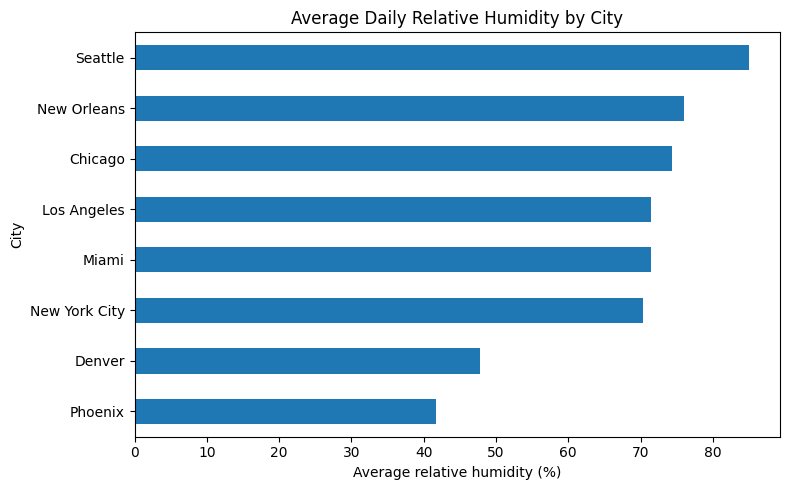

In [21]:
# Analytical question 2: Which city had the highest average humidity, and how does Seattle compare to the others?
# A horizontal bar chart fits because humidity is one continuous number per city, and side-by-side bars keep city labels readable.
humidity_by_city.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Average Daily Relative Humidity by City")
plt.xlabel("Average relative humidity (%)")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(charts_folder / "humidity_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

**Chart 2 finding:** **Seattle** had the highest average humidity at about **85%** — roughly **9 points** above the next city (New Orleans, ~76%). Seattle ranked **#1 of 8**, so it was the most humid city in this dataset, not just “somewhere in the middle.” That challenges the assumption that other cities are always more humid than Seattle in winter.

### Question 3: Which cities had the most cloudy, rainy, or clear days?

The tables summarize day-type percentages by city. The grouped bar chart compares clear, cloudy, and rainy day shares.

In [22]:
# This counts how many times each weather condition appears for each city.
# The answer tells me which cities had more clear days, rainy/drizzly days, cloudy days, snow days, and other conditions.
condition_counts_by_city = (
    df.groupby("city")["weather_condition"]
    .value_counts()
    .unstack(fill_value=0)
)

condition_counts_by_city

weather_condition,Clear,Partly cloudy/cloudy,Rain/drizzle,Snow
city,,,,
Chicago,0,40,14,36
Denver,3,64,9,14
Los Angeles,11,57,22,0
Miami,7,31,52,0
New Orleans,8,39,43,0
New York City,3,47,14,26
Phoenix,13,64,13,0
Seattle,0,34,49,7


In [23]:
# This converts condition counts into percentages for each city.
# The answer makes city comparisons easier because it shows the share of days in each condition category.
condition_percent_by_city = condition_counts_by_city.div(condition_counts_by_city.sum(axis=1), axis=0) * 100

condition_percent_by_city.round(1)

weather_condition,Clear,Partly cloudy/cloudy,Rain/drizzle,Snow
city,,,,
Chicago,0.0,44.4,15.6,40.0
Denver,3.3,71.1,10.0,15.6
Los Angeles,12.2,63.3,24.4,0.0
Miami,7.8,34.4,57.8,0.0
New Orleans,8.9,43.3,47.8,0.0
New York City,3.3,52.2,15.6,28.9
Phoenix,14.4,71.1,14.4,0.0
Seattle,0.0,37.8,54.4,7.8


In [24]:
# This groups by city and averages the true/false columns.
# Since True counts as 1 and False counts as 0, the mean becomes the percentage of days that match each condition.
weather_pattern_by_city = (
    df.groupby("city")[["is_clear_day", "is_cloudy_day", "is_rain_day"]]
    .mean()
    .mul(100)
    .sort_values("is_cloudy_day", ascending=False)
)

weather_pattern_by_city.round(1)

,is_clear_day,is_cloudy_day,is_rain_day
city,,,
Seattle,8.9,70.0,56.7
Chicago,10.0,64.4,43.3
New York City,14.4,47.8,37.8
New Orleans,30.0,32.2,41.1
Denver,18.9,31.1,17.8
Los Angeles,38.9,31.1,23.3
Phoenix,48.9,24.4,12.2
Miami,42.2,17.8,53.3


In [25]:
# This groups the same weather pattern columns by broad region.
# The answer can suggest rough regional patterns, but it should be interpreted carefully because each region only has one city in this dataset.
weather_pattern_by_region = (
    df.groupby("region")[["is_clear_day", "is_cloudy_day", "is_rain_day"]]
    .mean()
    .mul(100)
    .sort_values("is_cloudy_day", ascending=False)
)

weather_pattern_by_region.round(1)

,is_clear_day,is_cloudy_day,is_rain_day
region,,,
Pacific Northwest,8.9,70.0,56.7
Midwest,10.0,64.4,43.3
Northeast,14.4,47.8,37.8
Gulf South,30.0,32.2,41.1
Mountain West,18.9,31.1,17.8
West Coast,38.9,31.1,23.3
Southwest,48.9,24.4,12.2
Southeast,42.2,17.8,53.3


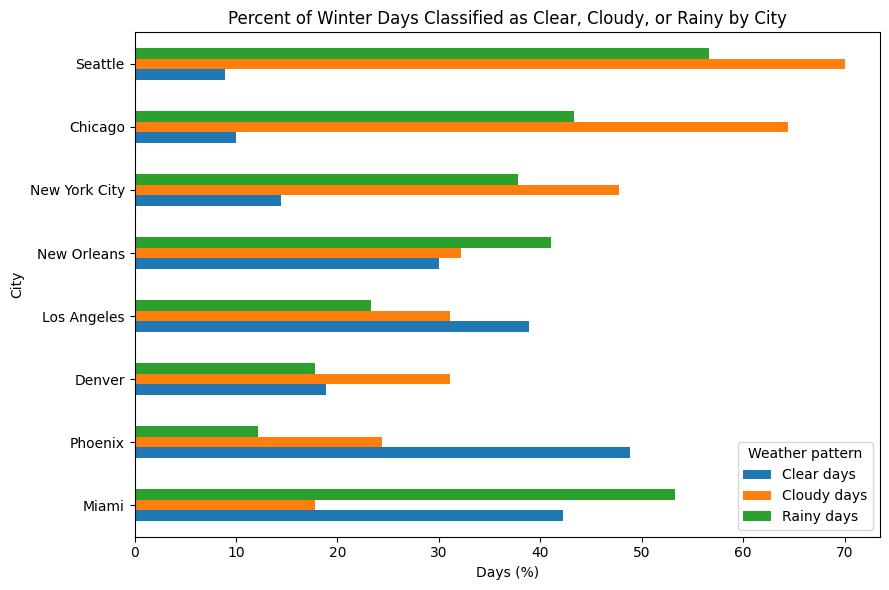

In [26]:
# Analytical question 3: Which cities had the most cloudy, rainy, or clear days, and are there rough patterns by region?
# A grouped horizontal bar chart fits because each city has three related percentages to compare at once, and grouping keeps the categories aligned for easier scanning.
weather_pattern_by_city.sort_values("is_cloudy_day")[["is_clear_day", "is_cloudy_day", "is_rain_day"]].plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Percent of Winter Days Classified as Clear, Cloudy, or Rainy by City")
plt.xlabel("Days (%)")
plt.ylabel("City")
plt.legend(["Clear days", "Cloudy days", "Rainy days"], title="Weather pattern")
plt.tight_layout()

plt.savefig(charts_folder / "weather_patterns_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

**Chart 3 finding:** **Seattle** and **Chicago** had the most **cloudy** days (~70% and ~64%). **Phoenix** and **Miami** had the most **clear** days (~49% and ~42%). **Seattle** also had the most **rainy** days (~57%), with Miami close behind (~53%). Regional snapshots (one city per region) suggest wetter, cloudier winters in the Pacific Northwest and Midwest entries and drier winters in the Southwest — but those regional conclusions should stay tentative.

## 4. Conclusions

### Question 1: Which city had the biggest average difference between actual temperature and “feels like” temperature?

Chicago had the largest average absolute feels-like gap in this winter dataset, with New York City and Denver also showing relatively large gaps. Los Angeles had the smallest gap, which suggests that “feels like” and actual temperature often matched more closely there. This implies that headline temperature can be misleading in colder or windier cities. With more time, I would break the gap into wind-driven vs humidity-driven components by day.

### Question 2: Which city had the highest average humidity, and how does Seattle compare?

Seattle had the highest average relative humidity (~85%) and ranked first among all eight cities — ahead of New Orleans, Chicago, and Miami. Seattle’s reputation for damp winter weather matches this dataset more strongly than a “middle of the pack” humidity ranking would. With more time, I would compare humidity alongside precipitation intensity and rainy-day counts to separate “humid” from “actively raining.”

### Question 3: Which cities had the most cloudy, rainy, or clear days, and are there any rough patterns by region?

Seattle led in both cloudy and rainy day percentages, while Phoenix and Miami had the highest clear-day shares. Regional groupings hint at cloudier winters in the Pacific Northwest and Midwest city chosen here, and clearer winters in the Southwest — but each region is represented by only one city. With more time, I would add more cities per region or compare the same analysis across seasons.

## 5. Process

I originally thought about comparing **current** weather across cities, but realized that would only give me **one row per city** — not enough for meaningful pandas analysis. I pivoted to **historical daily weather across a full winter season** so I could group, filter, and summarize patterns over time.

I chose **Open-Meteo** because it was accessible and provided historical daily weather without a complicated API setup. I selected **eight U.S. cities** to represent different winter climates. I used **pandas** to load the CSV, convert dates, check missing values, and build summary tables. I also created helper columns (`feels_like_gap_f`, `absolute_feels_like_gap_f`, `weather_condition`, `is_rain_day`, `is_cloudy_day`, `is_clear_day`) so each question was easier to answer.

My **A6 chart work** became the starting point for the Analysis section. I saved the final charts as **PNG files** in `charts/` so the project can be reviewed even if a reviewer does not rerun the notebook. The regional comparisons are intentionally limited because **each region label maps to only one city** in this dataset.